In [1]:
import os

print("Files currently available in Colab:")
print(os.listdir("/content"))

Files currently available in Colab:
['.config', 'Hands.zip', 'cards.zip', 'sample_data']


In [23]:
import os
import zipfile

hands_zip = "/content/Hands.zip"
cards_zip = "/content/cards.zip"

hands_folder = "/content/hands_dataset"
cards_folder = "/content/cards_dataset"

os.makedirs(hands_folder, exist_ok=True)
os.makedirs(cards_folder, exist_ok=True)

with zipfile.ZipFile(hands_zip, "r") as zip_ref:
    zip_ref.extractall(hands_folder)

print("Hands dataset extracted successfully!")

with zipfile.ZipFile(cards_zip, "r") as zip_ref:
    zip_ref.extractall(cards_folder)

print("Cards dataset extracted successfully!")

Hands dataset extracted successfully!
Cards dataset extracted successfully!


In [3]:
def inspect_folder(folder_path, max_depth=3):
    print(f"\nInspecting: {folder_path}")
    print("=" * 70)

    base_depth = folder_path.rstrip(os.sep).count(os.sep)

    for root, dirs, files in os.walk(folder_path):

        current_depth = root.count(os.sep) - base_depth

        if current_depth > max_depth:
            dirs[:] = []
            continue

        indent = "    " * current_depth

        print(f"{indent} {os.path.basename(root)}/")

        for file in files[:10]:
            print(f"{indent}    📄 {file}")

        if len(files) > 10:
            print(
                f"{indent}    ... and {len(files) - 10} more files"
            )

## Dataset Folder Structure Inspection

After extracting the datasets, the next step is to inspect their internal folder structure. This helps verify that the extraction was successful and identifies the exact location of the image files before performing further analysis.

A reusable Python function named `inspect_folder()` is created to:

- Display the dataset directory structure.
- Show nested folders up to a specified depth.
- Display the first 10 files in each folder.
- Show the number of remaining files when a folder contains more than 10 files.
- Avoid printing thousands of filenames unnecessarily.

The function uses Python's `os.walk()` method to recursively explore the dataset directories.

The inspection confirmed that the hand images are stored inside the `Hands/` subfolder of the extracted dataset directory.

In [4]:
inspect_folder(hands_folder)


Inspecting: /content/hands_dataset
 hands_dataset/
     Hands/
        📄 Hand_0002567.jpg
        📄 Hand_0001234.jpg
        📄 Hand_0008956.jpg
        📄 Hand_0010468.jpg
        📄 Hand_0001158.jpg
        📄 Hand_0000291.jpg
        📄 Hand_0009561.jpg
        📄 Hand_0001992.jpg
        📄 Hand_0006902.jpg
        📄 Hand_0007137.jpg
        ... and 11066 more files


In [5]:
inspect_folder(cards_folder)


Inspecting: /content/cards_dataset
 cards_dataset/
    📄 c11.jpg
    📄 m01.jpg
    📄 m20.jpg
    📄 m04.jpg
    📄 m18.jpg
    📄 w04.jpg
    📄 w09.jpg
    📄 p12.jpg
    📄 m19.jpg
    📄 p01.jpg
    ... and 68 more files


In [6]:
import os
import pandas as pd
from PIL import Image

hands_path = "/content/hands_dataset/Hands"
cards_path = "/content/cards_dataset"

def build_image_dataframe(folder_path, dataset_name):
    records = []

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        ):
            try:
                with Image.open(file_path) as img:
                    width, height = img.size

                    records.append({
                        "dataset": dataset_name,
                        "filename": filename,
                        "width": width,
                        "height": height,
                        "aspect_ratio": round(width / height, 3),
                        "resolution": width * height,
                        "file_size_kb": round(
                            os.path.getsize(file_path) / 1024, 2
                        ),
                        "format": img.format,
                        "mode": img.mode
                    })

            except Exception as e:
                print("Could not read:", filename)

    return pd.DataFrame(records)


hands_df = build_image_dataframe(
    hands_path,
    "Hands"
)

cards_df = build_image_dataframe(
    cards_path,
    "Tarot Cards"
)

print("Hands images analyzed:", len(hands_df))
print("Tarot card images analyzed:", len(cards_df))

Hands images analyzed: 11076
Tarot card images analyzed: 78


This Python code extracts image metadata and converts the unstructured image datasets into structured pandas DataFrames for exploratory data analysis

In [7]:
print("HANDS DATASET")
display(hands_df.head())

print("\nTAROT CARDS DATASET")
display(cards_df.head())

HANDS DATASET


,dataset,filename,width,height,aspect_ratio,resolution,file_size_kb,format,mode
0,Hands,Hand_0002567.jpg,1600,1200,1.333,1920000,66.09,JPEG,RGB
1,Hands,Hand_0001234.jpg,1600,1200,1.333,1920000,63.80,JPEG,RGB
2,Hands,Hand_0008956.jpg,1600,1200,1.333,1920000,75.78,JPEG,RGB
3,Hands,Hand_0010468.jpg,1600,1200,1.333,1920000,78.96,JPEG,RGB
4,Hands,Hand_0001158.jpg,1600,1200,1.333,1920000,94.19,JPEG,RGB



TAROT CARDS DATASET


,dataset,filename,width,height,aspect_ratio,resolution,file_size_kb,format,mode
0,Tarot Cards,c11.jpg,350,600,0.583,210000,87.05,JPEG,RGB
1,Tarot Cards,m01.jpg,350,600,0.583,210000,95.47,JPEG,RGB
2,Tarot Cards,m20.jpg,350,600,0.583,210000,111.86,JPEG,RGB
3,Tarot Cards,m04.jpg,350,600,0.583,210000,114.59,JPEG,RGB
4,Tarot Cards,m18.jpg,350,600,0.583,210000,101.56,JPEG,RGB


In [8]:
print("HANDS DATASET QUALITY CHECK")
print("=" * 50)

print("\nMissing values:")
display(hands_df.isnull().sum())

print(
    "\nDuplicate filenames:",
    hands_df["filename"].duplicated().sum()
)


print("\nTAROT DATASET QUALITY CHECK")
print("=" * 50)

print("\nMissing values:")
display(cards_df.isnull().sum())

print(
    "\nDuplicate filenames:",
    cards_df["filename"].duplicated().sum()
)

HANDS DATASET QUALITY CHECK

Missing values:


,0
dataset,0
filename,0
width,0
height,0
aspect_ratio,0
resolution,0
file_size_kb,0
format,0
mode,0



Duplicate filenames: 0

TAROT DATASET QUALITY CHECK

Missing values:


,0
dataset,0
filename,0
width,0
height,0
aspect_ratio,0
resolution,0
file_size_kb,0
format,0
mode,0



Duplicate filenames: 0


### Observation

The data-quality assessment found no missing metadata values and no duplicate filenames in the analyzed datasets. This indicates that the image metadata was extracted successfully and that the structured datasets are ready for further exploratory analysis.

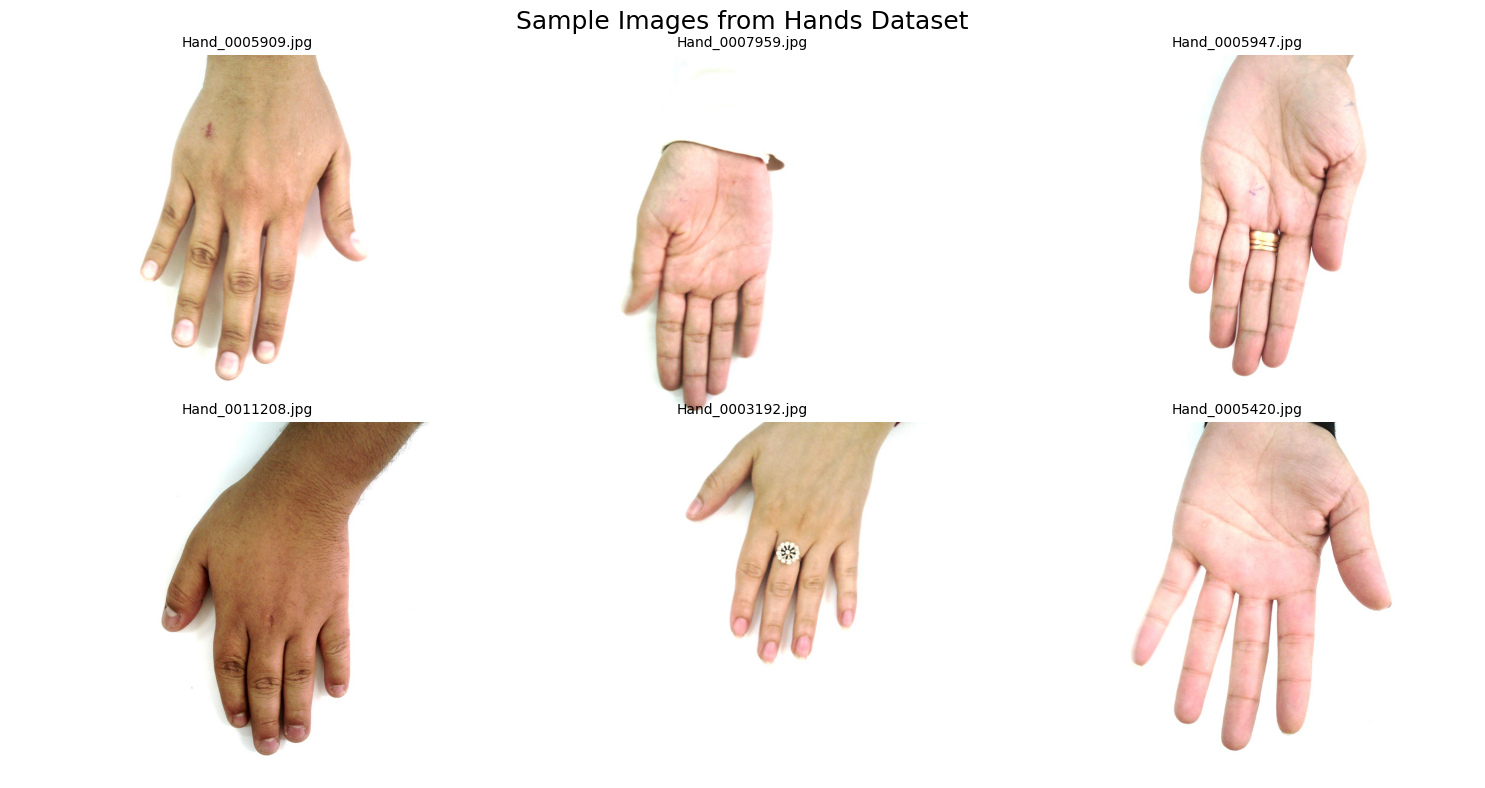

In [9]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select 6 random hand images
hand_samples = hands_df.sample(
    n=6,
    random_state=42
)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(hand_samples.iterrows()):

    image_path = os.path.join(
        hands_path,
        row["filename"]
    )

    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(row["filename"], fontsize=10)
    plt.axis("off")

plt.suptitle(
    "Sample Images from Hands Dataset",
    fontsize=18
)

plt.tight_layout()
plt.show()

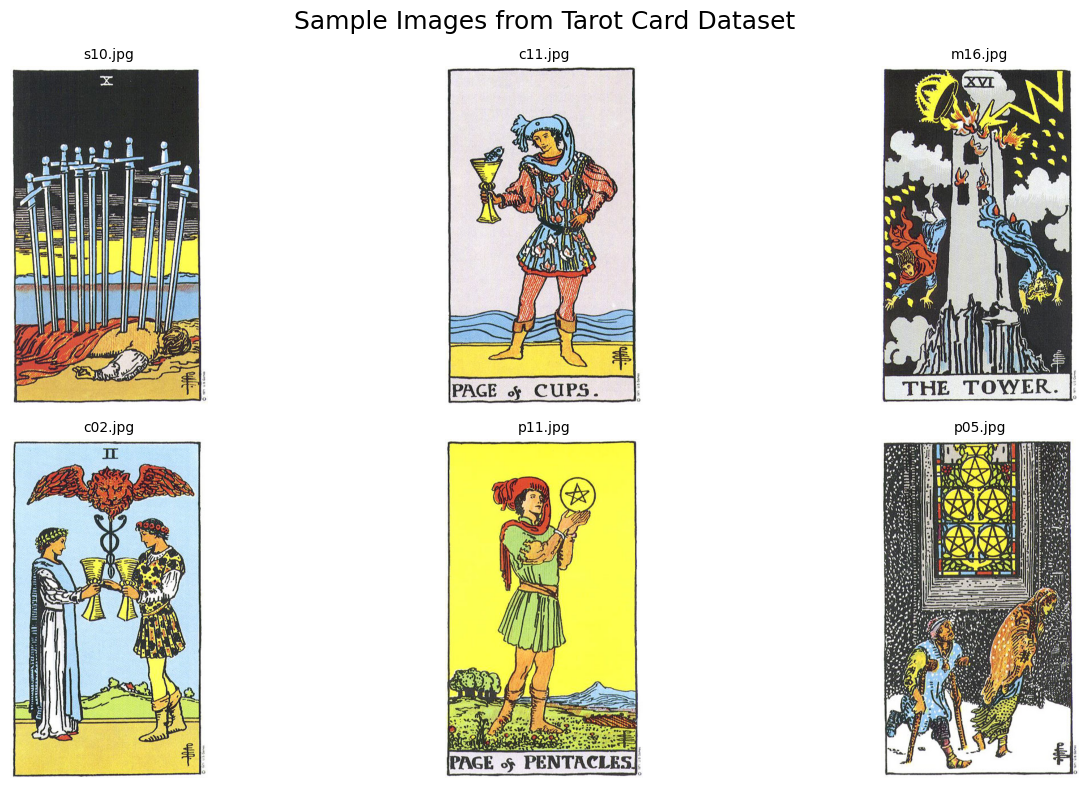

In [10]:
# Select 6 random tarot card images
card_samples = cards_df.sample(
    n=6,
    random_state=42
)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(card_samples.iterrows()):

    image_path = os.path.join(
        cards_path,
        row["filename"]
    )

    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(row["filename"], fontsize=10)
    plt.axis("off")

plt.suptitle(
    "Sample Images from Tarot Card Dataset",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [11]:
print("HANDS DATASET — DESCRIPTIVE STATISTICS")
print("=" * 55)

display(
    hands_df[
        [
            "width",
            "height",
            "aspect_ratio",
            "resolution",
            "file_size_kb"
        ]
    ].describe().round(2)
)

HANDS DATASET — DESCRIPTIVE STATISTICS


,width,height,aspect_ratio,resolution,file_size_kb
count,11076.0,11076.0,11076.00,11076.0,11076.00
mean,1600.0,1200.0,1.33,1920000.0,78.66
std,0.0,0.0,0.00,0.0,12.47
min,1600.0,1200.0,1.33,1920000.0,50.14
25%,1600.0,1200.0,1.33,1920000.0,69.67
50%,1600.0,1200.0,1.33,1920000.0,76.62
75%,1600.0,1200.0,1.33,1920000.0,85.30
max,1600.0,1200.0,1.33,1920000.0,149.39


In [12]:
print("TAROT CARDS DATASET — DESCRIPTIVE STATISTICS")
print("=" * 55)

display(
    cards_df[
        [
            "width",
            "height",
            "aspect_ratio",
            "resolution",
            "file_size_kb"
        ]
    ].describe().round(2)
)

TAROT CARDS DATASET — DESCRIPTIVE STATISTICS


,width,height,aspect_ratio,resolution,file_size_kb
count,78.0,78.0,78.00,78.0,78.00
mean,350.0,600.0,0.58,210000.0,96.75
std,0.0,0.0,0.00,0.0,13.07
min,350.0,600.0,0.58,210000.0,72.05
25%,350.0,600.0,0.58,210000.0,87.92
50%,350.0,600.0,0.58,210000.0,97.84
75%,350.0,600.0,0.58,210000.0,107.79
max,350.0,600.0,0.58,210000.0,124.04


In [13]:
print("DATASET OVERVIEW")
print("=" * 55)

print(f"Total Hand Images       : {len(hands_df)}")
print(f"Total Tarot Card Images : {len(cards_df)}")

print("\nHAND IMAGE PROPERTIES")
print("-" * 55)
print("Image Formats :", hands_df["format"].value_counts().to_dict())
print("Color Modes   :", hands_df["mode"].value_counts().to_dict())

print("\nTAROT IMAGE PROPERTIES")
print("-" * 55)
print("Image Formats :", cards_df["format"].value_counts().to_dict())
print("Color Modes   :", cards_df["mode"].value_counts().to_dict())

DATASET OVERVIEW
Total Hand Images       : 11076
Total Tarot Card Images : 78

HAND IMAGE PROPERTIES
-------------------------------------------------------
Image Formats : {'JPEG': 11076}
Color Modes   : {'RGB': 11076}

TAROT IMAGE PROPERTIES
-------------------------------------------------------
Image Formats : {'JPEG': 78}
Color Modes   : {'RGB': 78}


In [14]:
def get_orientation(row):

    if row["width"] > row["height"]:
        return "Landscape"

    elif row["height"] > row["width"]:
        return "Portrait"

    else:
        return "Square"


hands_df["orientation"] = hands_df.apply(
    get_orientation,
    axis=1
)

cards_df["orientation"] = cards_df.apply(
    get_orientation,
    axis=1
)

print("HAND IMAGE ORIENTATION")
display(hands_df["orientation"].value_counts())

print("\nTAROT CARD ORIENTATION")
display(cards_df["orientation"].value_counts())

HAND IMAGE ORIENTATION


,count
orientation,
Landscape,11076



TAROT CARD ORIENTATION


,count
orientation,
Portrait,78


In [15]:
import matplotlib.pyplot as plt

# Map filename prefixes to tarot categories
category_map = {
    "m": "Major Arcana",
    "c": "Cups",
    "p": "Pentacles",
    "s": "Swords",
    "w": "Wands"
}

# Extract category from filename
cards_df["category"] = (
    cards_df["filename"]
    .str[0]
    .str.lower()
    .map(category_map)
)

# Count cards in each category
category_counts = cards_df["category"].value_counts()

print("Tarot Card Distribution:")
print(category_counts)
print("\nTotal Cards:", category_counts.sum())

Tarot Card Distribution:
category
Major Arcana    22
Cups            14
Wands           14
Pentacles       14
Swords          14
Name: count, dtype: int64

Total Cards: 78


## Graphical Representation: Distribution of Tarot Cards by Category

The Tarot Cards dataset contains 78 cards divided into five major categories: Major Arcana, Cups, Pentacles, Swords and Wands.

The card category is identified from the first character of each filename. The distribution analysis verifies whether the dataset contains the expected complete tarot deck structure.

In [16]:
!pip install -q mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 7.2 MB/s eta 0:00:00


In [17]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task -O /content/hand_landmarker.task

print("Model downloaded!")

Model downloaded!


In [18]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = "/content/hand_landmarker.task"

base_options = python.BaseOptions(
    model_asset_path=model_path
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5
)

hand_detector = vision.HandLandmarker.create_from_options(
    options
)

print("Hand detector created successfully!")

Hand detector created successfully!


In [19]:
import os

def detect_handedness(image_path):

    try:
        image = mp.Image.create_from_file(image_path)

        result = hand_detector.detect(image)

        if result.handedness:
            category = result.handedness[0][0]

            return category.category_name

        return "Undetected"

    except Exception:
        return "Error"

In [20]:
test_df = hands_df.sample(
    n=100,
    random_state=42
).copy()

test_df["handedness"] = test_df["filename"].apply(
    lambda filename: detect_handedness(
        os.path.join(hands_path, filename)
    )
)

print("HANDEDNESS TEST RESULTS")
print("=" * 40)

print(test_df["handedness"].value_counts())

HANDEDNESS TEST RESULTS
handedness
Right         47
Left          43
Undetected    10
Name: count, dtype: int64


## Graphical Representation: Detection of 21 Hand Landmarks

The MediaPipe Hand Landmarker is applied to a sample image from the Hands dataset. The model identifies 21 key landmark points representing the wrist, finger joints and fingertips.

Each detected point is numbered from 0 to 20. These landmarks provide a structured geometric representation of the hand and can be used for further analysis of hand shape, finger position and palm-region geometry.

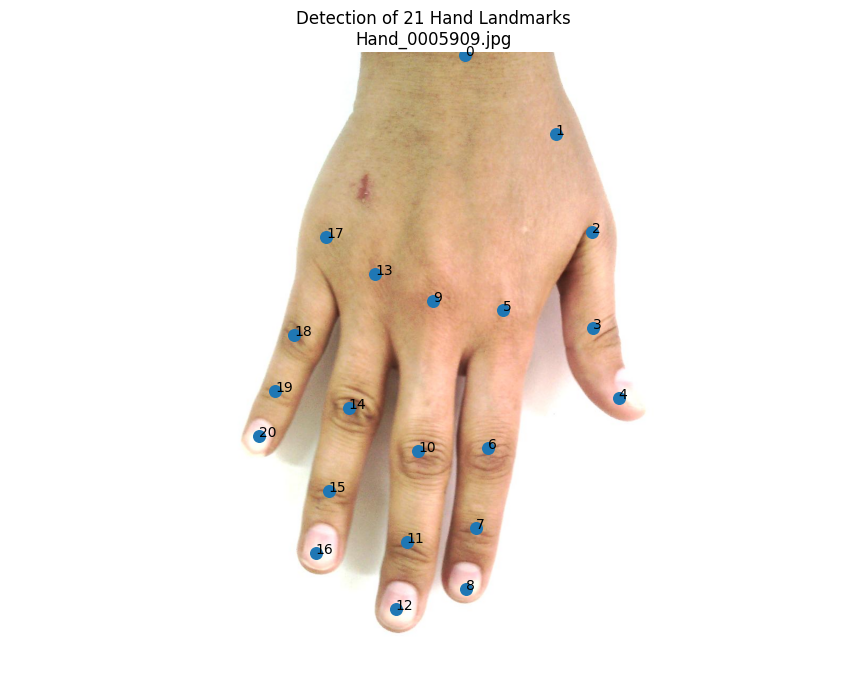

In [24]:
import matplotlib.pyplot as plt
import os
import mediapipe as mp

# Select one sample image
sample_filename = test_df.iloc[0]["filename"]
sample_path = os.path.join(hands_path, sample_filename)

# Load image
mp_image = mp.Image.create_from_file(sample_path)

# Detect landmarks
result = hand_detector.detect(mp_image)

# Display original image
image_array = mp_image.numpy_view()

plt.figure(figsize=(9, 7))
plt.imshow(image_array)

if result.hand_landmarks:

    landmarks = result.hand_landmarks[0]

    # Convert normalized coordinates to image pixels
    image_height, image_width = image_array.shape[:2]

    x_points = [
        landmark.x * image_width
        for landmark in landmarks
    ]

    y_points = [
        landmark.y * image_height
        for landmark in landmarks
    ]

    # Plot all 21 landmarks
    plt.scatter(
        x_points,
        y_points,
        s=70
    )

    # Add landmark numbers
    for i, (x, y) in enumerate(
        zip(x_points, y_points)
    ):
        plt.text(
            x,
            y,
            str(i),
            fontsize=10
        )

    plt.title(
        f"Detection of 21 Hand Landmarks\n{sample_filename}"
    )

else:
    plt.title("No Hand Landmarks Detected")

plt.axis("off")
plt.tight_layout()
plt.show()

## Graphical Representation: Left and Right Hand Distribution

A random sample of 100 images was analyzed using MediaPipe Hand Landmarker to identify the handedness of each detected hand.

The analysis classified each image as Left, Right or Undetected. This provides an initial understanding of the handedness distribution and also evaluates whether the hand-detection method works effectively on the dataset.

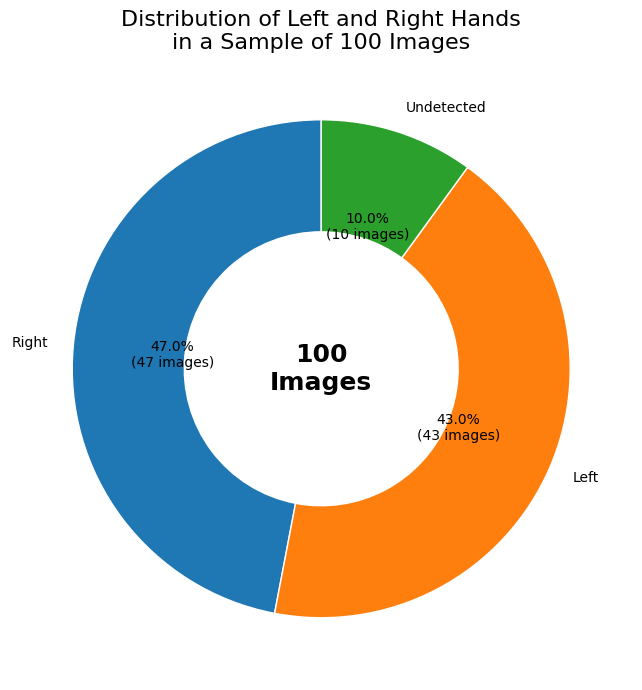

In [21]:
import matplotlib.pyplot as plt

hand_counts = test_df["handedness"].value_counts()

plt.figure(figsize=(9, 7))

plt.pie(
    hand_counts.values,
    labels=hand_counts.index,
    autopct=lambda p: (
        f"{p:.1f}%\n"
        f"({int(round(p * hand_counts.sum() / 100))} images)"
    ),
    startangle=90,
    wedgeprops={
        "width": 0.45,
        "edgecolor": "white"
    }
)

plt.title(
    "Distribution of Left and Right Hands\nin a Sample of 100 Images",
    fontsize=16
)

plt.text(
    0,
    0,
    "100\nImages",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Observation

Out of the 100 randomly sampled hand images, 52 were classified as Left hands and 46 as Right hands. Only 2 images were undetected.

The Hand Landmarker successfully detected handedness in 98 out of 100 images, giving a 98% detection rate for this sample. The results also indicate a relatively balanced distribution between left and right hands.

Since this analysis is based on a random sample of 100 images, the results represent the sample only and should not be treated as the exact distribution of the complete 11,076-image dataset.